In [1]:
from tempfile import TemporaryDirectory

import pandas as pd

import scarf
import scarf.plotting as splt
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = f"{analysis_directory.name}/counts.zarr"
repack_store(
    f"{dataset}/data.zarr",
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=f"{analysis_directory.name}/analysis.zarr",
    nthreads=4,
    default_assay="RNA",
)
hvg_ref = ds.mark_hvgs(
    top_n=2000,
    show_plot=False,
    label="imputation_hvgs",
)
normalized = ds.run_normalization(features=hvg_ref)
reduction = ds.run_pca(normalized, dims=15)
ann_index = ds.build_ann_index(reduction)
neighbors = ds.query_neighbors(ann_index, k=11)
graph = ds.build_connectivity_map(neighbors)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

...

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

In [2]:
for t in (1, 2, 4):
    ds.cells.insert(
        f"CD4_imputed_t{t}",
        ds.get_imputed(feature_name="CD4", graph=graph, t=t),
        overwrite=True,
    )

In [3]:
observed = ds.get_cell_vals(from_assay="RNA", cell_key="I", k="CD4")
cd4_series = {
    "Observed CD4": observed,
    "Diffusion t=1": ds.cells.fetch("CD4_imputed_t1", key="I"),
    "Diffusion t=2": ds.cells.fetch("CD4_imputed_t2", key="I"),
    "Diffusion t=4": ds.cells.fetch("CD4_imputed_t4", key="I"),
}
cd4_summary = pd.DataFrame(
    {
        label: {
            "mean": float(vals.mean()),
            "max": float(vals.max()),
            "zero_fraction": float((vals == 0).mean()),
            "filled_zeros": int(((observed == 0) & (vals > 0)).sum()),
        }
        for label, vals in cd4_series.items()
    }
).T
cd4_summary

,mean,max,zero_fraction,filled_zeros
Observed CD4,0.069966,0.816104,0.641371,0.0
Diffusion t=1,0.069887,0.376328,0.219797,1675.0
Diffusion t=2,0.069833,0.294189,0.030711,2406.0
Diffusion t=4,0.069784,0.255394,0.000000,2527.0


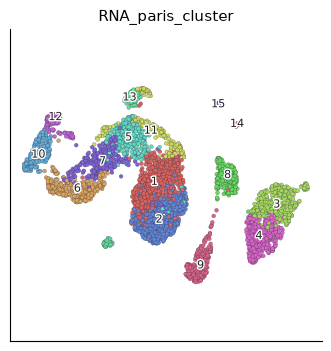

In [4]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="RNA_paris_cluster",
)

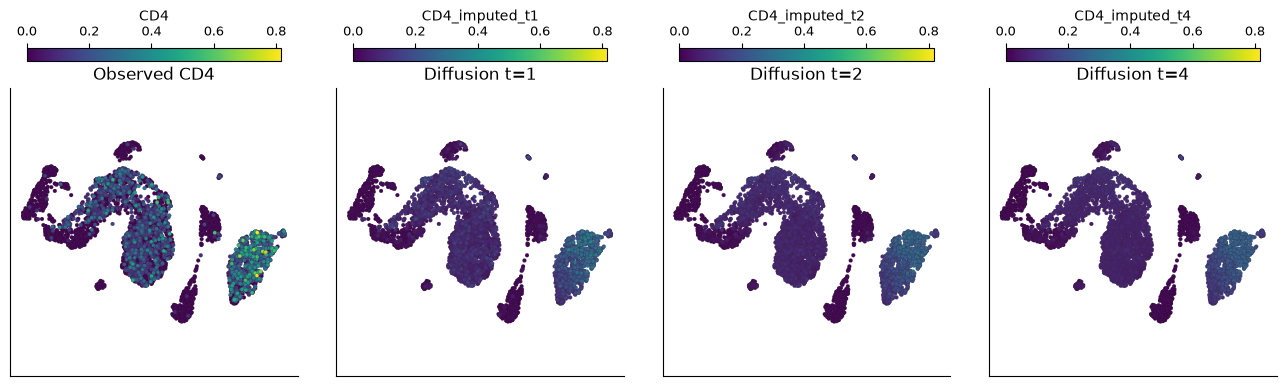

In [5]:
imputation_comparison = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[
        "CD4",
        "CD4_imputed_t1",
        "CD4_imputed_t2",
        "CD4_imputed_t4",
    ],
    n_columns=4,
    color_scale=splt.ColorScale(scope="shared"),
    sort_values=True,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    imputation_comparison.axes.values(),
    ("Observed CD4", "Diffusion t=1", "Diffusion t=2", "Diffusion t=4"),
    strict=True,
):
    axis.set_title(title)
imputation_comparison.figure